In [2]:
import re
from pathlib import Path
import pandas as pd

# ============================================================
# 0. 경로 / 기본 설정
# ============================================================

SCRIPT_DIR = Path("/Users/parkdahyeon/Documents/my_ws/lecturesight/data")

LAST_SECTION_RATIO = 0.08
MIN_LAST_BLOCKS = 20

PREV_CHARS_SUMMARY = 200
PREV_CHARS_END = 800
FALLBACK_CHARS = 3000   # = DEFAULT_MAX_CONTEXT_CHARS: 신호 없을 때 섹션 맨 끝 3000자

# 최종 기본값 후보
DEFAULT_MAX_CONTEXT_CHARS = 3000

# 길이 비교 실험용
MAX_CONTEXT_CONFIGS = [3000]

In [3]:
# ============================================================
# 1. 후보 키워드 패턴
# ============================================================

# 교사가 명시적으로 요약을 선언하는 표현만 유지
# (수업 중 일반적으로도 쓰이는 표현은 제거)
SUMMARY_CANDIDATE_PATTERNS = [
    r"정리하자면",
    r"정리하면",
    r"정리해\s*보면",
    r"정리\s*해보면",
    r"한번\s*정리",
    r"정리를\s*살짝",
    r"요약하자면",
    r"요약하면",
    r"오늘\s*(배운|배웠던|다룬|했던)\s*(내용|것|부분)",
    r"이번\s*시간에\s*(배운|다룬|했던)",
]

# 수업 종료를 나타내는 강한 신호 (summary가 없을 때 위치 추정용 프록시)
STRONG_END_PATTERNS = [
    r"오늘은\s*여기까지",
    r"오늘은\s*여기까.{0,3}",
    r"여기까지\s*하겠습니다",
    r"여기까지\s*할게요",
    r"여기까지\s*하도록",
    r"수업\s*마치겠습니다",
    r"마치도록\s*하겠습니다",

    r"고생하셨습니다",
    r"고생\s*많으셨습니다",
    r"수고하셨습니다",
    r"수고\s*많으셨습니다",

    r"내일\s*보겠습니다",
    r"다음\s*시간에",
    r"내일은.{0,80}(진행|학습|보겠습니다|하겠습니다)",
    r"다음에는.{0,80}(진행|학습|보겠습니다|하겠습니다)",
]

WEAK_END_PATTERNS = [
    r"쉬었다가",
    r"\d+\s*분\s*쉬",
]

In [95]:
# ============================================================
# 2. txt 라인 파싱
# ============================================================

def extract_timestamp_blocks(raw_text):
    """
    파일 형식:
    <09:11:17> b54f46b0: 발화내용

    timestamp는 실제 시각일 수 있으므로 시간 계산에 쓰지 않는다.
    파일 내 등장 순서만 사용한다.
    """
    blocks = []

    line_pattern = re.compile(
        r"^\s*<(?P<timestamp>\d{2}:\d{2}:\d{2})>\s*"
        r"(?P<speaker>[a-f0-9]{8}):\s*"
        r"(?P<text>.*)\s*$"
    )

    for line_index, line in enumerate(raw_text.splitlines()):
        match = line_pattern.match(line)

        if not match:
            continue

        text = match.group("text")
        text = re.sub(r"\s+", " ", text).strip()

        if not text:
            continue

        blocks.append({
            "line_index": line_index,
            "block_index": len(blocks),
            "timestamp": match.group("timestamp"),
            "speaker": match.group("speaker"),
            "text": text,
        })

    return blocks


def extract_last_section_by_order(blocks, ratio=0.15, min_blocks=20):
    """
    파일 순서 기준 마지막 ratio 구간 추출.
    timestamp 값은 사용하지 않는다.
    """
    if not blocks:
        return [], None, None, None

    n = len(blocks)

    last_n = max(min_blocks, int(n * ratio))
    last_n = min(last_n, n)

    start_index = n - last_n
    end_index = n - 1

    last_blocks = blocks[start_index:]

    return last_blocks, start_index, end_index, last_n

In [96]:
# ============================================================
# 3. Regex 매칭
# ============================================================

def find_first_regex_match(text, patterns):
    matches = []
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            matches.append({
                "start": match.start(),
                "end": match.end(),
                "matched_text": match.group(),
                "matched_pattern": pattern,
            })
    if not matches:
        return None
    return sorted(matches, key=lambda x: x["start"])[0]


def find_last_regex_match(text, patterns):
    matches = []
    for pattern in patterns:
        for match in re.finditer(pattern, text):
            matches.append({
                "start": match.start(),
                "end": match.end(),
                "matched_text": match.group(),
                "matched_pattern": pattern,
            })
    if not matches:
        return None
    return sorted(matches, key=lambda x: x["start"])[-1]


def find_all_regex_matches(text, patterns, max_items=20):
    matches = []
    for pattern in patterns:
        for match in re.finditer(pattern, text):
            matches.append({
                "start": match.start(),
                "end": match.end(),
                "matched_text": match.group(),
                "matched_pattern": pattern,
            })
    matches = sorted(matches, key=lambda x: x["start"])
    return matches[:max_items]


def format_matches(matches):
    if not matches:
        return ""
    return " || ".join([
        f"[pos={m['start']}, match={m['matched_text']}, pattern={m['matched_pattern']}]"
        for m in matches
    ])

In [97]:
# ============================================================
# 4. LLM 입력 context 생성
# ============================================================

def build_llm_input_context_by_char(
    section_text,
    prev_chars_summary=200,
    prev_chars_end=800,
    fallback_chars=4000,
    max_context_chars=None
):
    """
    목표: LLM에 넘길 요약 문맥 추출

    우선순위:
    1. summary  → 교사가 명시적으로 요약을 선언한 지점 (가장 직접적)
    2. strong_end → summary 없을 때, 마무리 발화 앞 800자로 요약 위치 추정 (프록시)
    3. weak_end → 쉬는 시간 발화 기준
    4. fallback → 아무 신호 없을 때 마지막 N자

    탐지 방식: last match (마지막 8% 구간 내 가장 마지막 등장 위치 사용)
    길이 제한: max_context_chars 초과 시 앞에서부터 자름 (트리거 기준 유지)
    """
    summary_match    = find_last_regex_match(section_text, SUMMARY_CANDIDATE_PATTERNS)
    strong_end_match = find_last_regex_match(section_text, STRONG_END_PATTERNS)
    weak_end_match   = find_last_regex_match(section_text, WEAK_END_PATTERNS)

    summary_matches    = find_all_regex_matches(section_text, SUMMARY_CANDIDATE_PATTERNS)
    strong_end_matches = find_all_regex_matches(section_text, STRONG_END_PATTERNS)
    weak_end_matches   = find_all_regex_matches(section_text, WEAK_END_PATTERNS)

    if summary_match:
        start = max(0, summary_match["start"] - prev_chars_summary)

        extraction_type    = "summary_signal_based_char"
        matched_text       = summary_match["matched_text"]
        matched_pattern    = summary_match["matched_pattern"]
        trigger_char_index = summary_match["start"]

    elif strong_end_match:
        start = max(0, strong_end_match["start"] - prev_chars_end)

        extraction_type    = "strong_end_signal_based_char"
        matched_text       = strong_end_match["matched_text"]
        matched_pattern    = strong_end_match["matched_pattern"]
        trigger_char_index = strong_end_match["start"]

    elif weak_end_match:
        start = max(0, weak_end_match["start"] - prev_chars_end)

        extraction_type    = "weak_end_signal_based_char"
        matched_text       = weak_end_match["matched_text"]
        matched_pattern    = weak_end_match["matched_pattern"]
        trigger_char_index = weak_end_match["start"]

    else:
        start = max(0, len(section_text) - fallback_chars)

        extraction_type    = "fallback_last_chars"
        matched_text       = ""
        matched_pattern    = ""
        trigger_char_index = ""

    context_before_limit = section_text[start:]
    context_before_limit = re.sub(r"\s+", " ", context_before_limit).strip()

    original_context_char_count = len(context_before_limit)

    if max_context_chars is not None and len(context_before_limit) > max_context_chars:
        context = context_before_limit[:max_context_chars]
        is_truncated_by_max_length = True
    else:
        context = context_before_limit
        is_truncated_by_max_length = False

    return {
        "extraction_type": extraction_type,
        "matched_text": matched_text,
        "matched_pattern": matched_pattern,
        "trigger_char_index_in_section": trigger_char_index,
        "start_char_index_in_section": start,

        "original_context_char_count": original_context_char_count,
        "max_context_chars": max_context_chars,
        "is_truncated_by_max_length": is_truncated_by_max_length,
        "llm_input_char_count": len(context),
        "llm_input_context": context,

        "summary_matches": summary_matches,
        "strong_end_matches": strong_end_matches,
        "weak_end_matches": weak_end_matches,
    }

In [98]:
# ============================================================
# 5. 파일 1개 처리
# ============================================================

def extract_llm_input_from_file(
    file_path,
    last_section_ratio=0.15,
    min_last_blocks=20,
    prev_chars_summary=700,
    prev_chars_end=1200,
    fallback_chars=4000,
    max_context_chars=None
):
    raw_text = file_path.read_text(encoding="utf-8", errors="ignore")

    # 1) timestamp 발화 라인 추출
    blocks = extract_timestamp_blocks(raw_text)

    # 2) 파일 순서 기준 마지막 15% 선택
    last_blocks, start_block_index, end_block_index, last_block_count = extract_last_section_by_order(
        blocks,
        ratio=last_section_ratio,
        min_blocks=min_last_blocks
    )

    # 3) 마지막 15% 블록 결합
    section_text = " ".join(block["text"] for block in last_blocks)
    section_text = re.sub(r"\s+", " ", section_text).strip()

    # 4) LLM 입력 context 생성
    llm_context_info = build_llm_input_context_by_char(
        section_text,
        prev_chars_summary=prev_chars_summary,
        prev_chars_end=prev_chars_end,
        fallback_chars=fallback_chars,
        max_context_chars=max_context_chars
    )

    return {
        "file": file_path.name,

        "extraction_type": llm_context_info["extraction_type"],
        "matched_text": llm_context_info["matched_text"],
        "matched_pattern": llm_context_info["matched_pattern"],
        "trigger_char_index_in_section": llm_context_info["trigger_char_index_in_section"],
        "start_char_index_in_section": llm_context_info["start_char_index_in_section"],

        "summary_matches": format_matches(llm_context_info["summary_matches"]),
        "strong_end_matches": format_matches(llm_context_info["strong_end_matches"]),
        "weak_end_matches": format_matches(llm_context_info["weak_end_matches"]),

        "total_timestamp_blocks": len(blocks),
        "last15_timestamp_blocks": len(last_blocks),
        "last15_start_block_index": start_block_index,
        "last15_end_block_index": end_block_index,
        "last15_block_ratio": round(len(last_blocks) / len(blocks), 3) if blocks else 0,

        "last15_start_timestamp": last_blocks[0]["timestamp"] if last_blocks else "",
        "last15_end_timestamp": last_blocks[-1]["timestamp"] if last_blocks else "",

        "raw_char_count": len(raw_text),
        "section_char_count": len(section_text),
        "original_context_char_count": llm_context_info["original_context_char_count"],
        "max_context_chars": llm_context_info["max_context_chars"],
        "is_truncated_by_max_length": llm_context_info["is_truncated_by_max_length"],
        "llm_input_char_count": llm_context_info["llm_input_char_count"],

        "section_text_sample": section_text[:1000],
        "llm_input_context": llm_context_info["llm_input_context"],
    }

In [99]:
# ============================================================
# 6. 기본 설정으로 최종 LLM 입력 생성
# ============================================================

final_rows = []

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    print("=" * 70)
    print(f"[파일] {file_path.name}")
    print("=" * 70)

    row = extract_llm_input_from_file(
        file_path,
        last_section_ratio=LAST_SECTION_RATIO,
        min_last_blocks=MIN_LAST_BLOCKS,
        prev_chars_summary=PREV_CHARS_SUMMARY,
        prev_chars_end=PREV_CHARS_END,
        fallback_chars=FALLBACK_CHARS,
        max_context_chars=DEFAULT_MAX_CONTEXT_CHARS
    )

    print(f"  extraction_type      : {row['extraction_type']}")
    print(f"  matched_text         : {row['matched_text']}")
    print(f"  matched_pattern      : {row['matched_pattern']}")
    print(f"  total_blocks         : {row['total_timestamp_blocks']}")
    print(f"  last15_blocks        : {row['last15_timestamp_blocks']} ({row['last15_start_timestamp']} ~ {row['last15_end_timestamp']})")
    print(f"  section_char_count   : {row['section_char_count']}")
    print(f"  original_context_chars : {row['original_context_char_count']}")
    print(f"  llm_input_chars      : {row['llm_input_char_count']} (truncated={row['is_truncated_by_max_length']})")
    print(f"  summary_matches      : {row['summary_matches'] or '없음'}")
    print(f"  strong_end_matches   : {row['strong_end_matches'] or '없음'}")
    print(f"  weak_end_matches     : {row['weak_end_matches'] or '없음'}")
    print()
    print("[llm_input_context]")
    print(row["llm_input_context"])
    print()

    final_rows.append(row)

llm_input_df = pd.DataFrame(final_rows)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

llm_input_df.to_csv(
    "summary_llm_input_contexts_final.csv",
    index=False,
    encoding="utf-8-sig"
)

[파일] 2026-02-02_kdt-backendj-21th.txt
  extraction_type      : strong_end_signal_based_char
  matched_text         : 내일은 이제 데이터베이스를 진행
  matched_pattern      : 내일은.{0,80}(진행|학습|보겠습니다|하겠습니다)
  total_blocks         : 1484
  last15_blocks        : 118 (03:39:50 ~ 04:10:39)
  section_char_count   : 6317
  original_context_chars : 3956
  llm_input_chars      : 3000 (truncated=True)
  summary_matches      : 없음
  strong_end_matches   : [pos=3160, match=내일은 이제 데이터베이스를 진행, pattern=내일은.{0,80}(진행|학습|보겠습니다|하겠습니다)]
  weak_end_matches     : 없음

[llm_input_context]
과목마다 프로젝트가 있는데, 그래야 내가 자바 회사 갈 때 이걸 들고 가지 자바 회사 웹사이트 만들어서 들고 갈 수는 없잖아. 그런데 의외로 순수 자바런 하는 회사들도 되게 많고 여러분 그 기업에 가면 상사 있죠. 상사 롯데상사나 상사 있죠. 외국 이렇게 물건 이렇게 사는 거 상사가 의외로 많은데 그 상사는 순수 잡아라 거기 가면 다 또 일반 자기네만의 자바를 또 만들어 놨거든요. 그러니까 회사들이 자본자본 많기 때문에 또 그런 데 가려고 토크는 또 알아야 돼서 고민은 하고 있지만 하루라도 하지 않을까? 싶습니다. 그냥 여러분들이 아 이런 게 네트워크야 별건 없네 약간 이런 느낌 되셨어요. 오늘은 I이O하고 N아IO2를 이제 기점으로 봤고 내일 아침에 와서 DB 들어가기 전에 길을 한번 가서 제가 한번 짚고 갈 거거든요. 이거 가시면 파에 NIO HTML 같은 경우에는 가면 아까처럼

In [89]:
# ============================================================
# 8. 트리거 위치 분포 분석 (lookback 값 근거 도출)
# ============================================================

def find_all_hits(text, patterns):
    hits = [(m.start(), m.group()) for p in patterns for m in re.finditer(p, text)]
    return sorted(hits)

rows_dist = []

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    raw = file_path.read_text(encoding="utf-8", errors="ignore")
    blocks = extract_timestamp_blocks(raw)
    n = len(blocks)
    last_n = max(MIN_LAST_BLOCKS, int(n * LAST_SECTION_RATIO))
    section = re.sub(r"\s+", " ", " ".join(b["text"] for b in blocks[-last_n:])).strip()
    total = len(section)

    summary_hits = find_all_hits(section, SUMMARY_CANDIDATE_PATTERNS)
    strong_hits  = find_all_hits(section, STRONG_END_PATTERNS)

    last_s = summary_hits[-1] if summary_hits else None
    last_e = strong_hits[-1]  if strong_hits  else None

    s_pos    = last_s[0] if last_s else None
    e_pos    = last_e[0] if last_e else None
    s_pct    = round(s_pos / total * 100, 1) if s_pos is not None else None
    e_pct    = round(e_pos / total * 100, 1) if e_pos is not None else None
    s_to_end = (total - s_pos) if s_pos is not None else None
    e_to_end = (total - e_pos) if e_pos is not None else None
    gap      = (e_pos - s_pos) if (s_pos is not None and e_pos is not None) else None

    rows_dist.append({
        "file": file_path.name[:10],
        "section_total": total,
        "summary_pos": s_pos,
        "summary_pct": s_pct,
        "summary_word": last_s[1][:12] if last_s else "-",
        "strong_pos": e_pos,
        "strong_pct": e_pct,
        "strong_word": last_e[1][:12] if last_e else "-",
        "summary→end": s_to_end,
        "strong→end": e_to_end,
        "summary→strong": gap,
    })

# 테이블 출력
print(f"{'파일':<12} {'total':>6} {'sum%':>6} {'sum_word':<14} {'end%':>6} {'end_word':<14} {'sum→end':>8} {'end→end':>8} {'gap':>6}")
print("-" * 95)
for r in rows_dist:
    print(
        f"{r['file']:<12} {r['section_total']:>6} "
        f"{str(r['summary_pct'] or '-'):>6} {r['summary_word']:<14} "
        f"{str(r['strong_pct'] or '-'):>6} {r['strong_word']:<14} "
        f"{str(r['summary→end'] or '-'):>8} {str(r['strong→end'] or '-'):>8} "
        f"{str(r['summary→strong'] or '-'):>6}"
    )

print()

# 요약 통계
s2e = [r['summary→end'] for r in rows_dist if r['summary→end'] is not None]
e2e = [r['strong→end']  for r in rows_dist if r['strong→end']  is not None]
gaps = [r['summary→strong'] for r in rows_dist if r['summary→strong'] is not None]
spcts = [r['summary_pct'] for r in rows_dist if r['summary_pct'] is not None]

print(f"[summary 위치 (섹션 내 %)] {sorted(spcts)}")
print(f"  → 70% 미만은 강의 중간 리뷰일 가능성 높음 (오탐 주의)")

print(f"\n[strong_end→end 거리]  min={min(e2e)}  max={max(e2e)}  avg={sum(e2e)//len(e2e)}자  ({len(e2e)}개 파일)")
print(f"  → strong_end는 대부분 섹션 맨 끝 문장 (거리=8~30자)")
print(f"  → prev_chars_end = 섹션 끝에서 얼마나 올라갈지")

if gaps:
    print(f"\n[summary→strong 갭]  min={min(gaps)}  max={max(gaps)}  avg={sum(gaps)//len(gaps)}자  ({len(gaps)}개 파일)")
    print(f"  → 요약 신호와 종료 신호 사이 거리 (진짜 요약 길이 하한)")

print(f"\n[현재 설정] prev_chars_summary={PREV_CHARS_SUMMARY}  prev_chars_end={PREV_CHARS_END}")

# 파일별 주변 텍스트 확인
print("\n" + "=" * 60)
print("[summary 신호 파일별 트리거 주변 텍스트 (±200자)]")
print("=" * 60)
for r in rows_dist:
    if r['summary_pos'] is None:
        continue
    raw = Path(SCRIPT_DIR / f"{r['file']}_kdt-backendj-21th.txt").read_text(encoding="utf-8", errors="ignore")
    blocks_f = extract_timestamp_blocks(raw)
    n_f = len(blocks_f)
    last_n_f = max(MIN_LAST_BLOCKS, int(n_f * LAST_SECTION_RATIO))
    sec_f = re.sub(r"\s+", " ", " ".join(b["text"] for b in blocks_f[-last_n_f:])).strip()
    pos = r['summary_pos']
    ctx = sec_f[max(0, pos-100):pos+250]
    print(f"\n[{r['file']}] pos={pos} ({r['summary_pct']}%) word='{r['summary_word']}'")
    print(f"  ...{ctx}...")

파일            total   sum% sum_word         end% end_word        sum→end  end→end    gap
-----------------------------------------------------------------------------------------------
2026-02-02     6317      - -                50.0 내일은 이제 데이터베이          -     3157      -
2026-02-03     6894      - -                99.8 고생하셨습니다               -       11      -
2026-02-04     6731      - -                99.8 수고 많으셨습니다             -       14      -
2026-02-05     5861      - -                   - -                     -        -      -
2026-02-06     7016   51.5 정리를 살짝           55.0 오늘은 여기까도 저         3402     3160    242
2026-02-09     6215      - -                99.7 여기까지 하도록              -       16      -
2026-02-10     6310      - -                99.8 고생 많으셨습니다             -       10      -
2026-02-11     6659      - -                99.9 고생하셨습니다               -        8      -
2026-02-12     4234      - -                   - -                     -        -      -
2026-02-13    

In [90]:
# ============================================================
# 9. prev_chars 값 비교 실험
#    - 값을 직접 바꿔가며 실행해서 context 차이 확인
# ============================================================

# ▼ 여기서 값 바꾸면서 실험
TEST_PREV_CHARS_SUMMARY = 200   # 현재: 700
TEST_PREV_CHARS_END     = 2000  # 현재: 1200

# 확인할 파일 지정 (None이면 전체 출력)
TARGET_FILES = None  # 예: ["2026-02-06", "2026-02-11", "2026-02-27"]

print(f"[실험 설정] prev_chars_summary={TEST_PREV_CHARS_SUMMARY}  prev_chars_end={TEST_PREV_CHARS_END}")
print(f"            last_section_ratio={LAST_SECTION_RATIO}  max_context_chars={DEFAULT_MAX_CONTEXT_CHARS}")
print("=" * 70)

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    fname = file_path.name[:10]
    if TARGET_FILES and not any(t in fname for t in TARGET_FILES):
        continue

    row = extract_llm_input_from_file(
        file_path,
        last_section_ratio=LAST_SECTION_RATIO,
        min_last_blocks=MIN_LAST_BLOCKS,
        prev_chars_summary=TEST_PREV_CHARS_SUMMARY,
        prev_chars_end=TEST_PREV_CHARS_END,
        fallback_chars=FALLBACK_CHARS,
        max_context_chars=DEFAULT_MAX_CONTEXT_CHARS,
    )

    trigger_pos = row["trigger_char_index_in_section"]
    start_pos   = row["start_char_index_in_section"]

    print(f"\n[{fname}]")
    print(f"  type    : {row['extraction_type']}")
    print(f"  trigger : '{row['matched_text']}'  pos={trigger_pos}")
    print(f"  start   : {start_pos}  (trigger - {TEST_PREV_CHARS_SUMMARY if 'summary' in row['extraction_type'] else TEST_PREV_CHARS_END})")
    print(f"  context : {row['llm_input_char_count']}자  (truncated={row['is_truncated_by_max_length']})")
    print(f"  --- context 앞 200자 ---")
    print(f"  {row['llm_input_context'][:200]}")
    print(f"  --- context 뒤 200자 ---")
    print(f"  {row['llm_input_context'][-200:]}")

[실험 설정] prev_chars_summary=200  prev_chars_end=2000
            last_section_ratio=0.08  max_context_chars=3000

[2026-02-02]
  type    : strong_end_signal_based_char
  trigger : '내일은 이제 데이터베이스를 진행'  pos=3160
  start   : 1160  (trigger - 2000)
  context : 3000자  (truncated=True)
  --- context 앞 200자 ---
  가 해주는 이벤트야 되셨어요. 이렇게 해서 이게 거진 IO하고 NIO2가 끝났어요. 끝났는데 일단은 남은 게 뭐야? 그냥 NIO잖아. 그런데 NIO는 우리가 일반적으로 파일 입출력할 때 쓰는 게 아니라 서버하고 클라이언트를 만들어 놓고 다중통신 멀티 스리딩을 할 때 쓰는 용어들이야 서버 클라이언트 주체가 반드시 그래도 궁금하다 그래서 바이트 단위로 할 때 
  --- context 뒤 200자 ---
  한 거 많아 여기 밑에 조금 보세요. 리소스라는 런에 보시면 AI는 뭐고부터 시작해서 뉴스도 나오고 컨텍스트 뉴스도 나오고 이렇게 해서 맨 처음에 프로덕트를 선택해서 들어오면 기본적으로 마이에스큐엘 엔터프라이즈로 살짝 넘어가는 걸 확인할 수가 있다. 그리고 여기가 AI 데이터베이스가 가지고 있는 AI 내장되어 있는 분석 툴이야 우리가 이 엔터프라이즈 에디션

[2026-02-03]
  type    : strong_end_signal_based_char
  trigger : '고생하셨습니다'  pos=6883
  start   : 4883  (trigger - 2000)
  context : 2011자  (truncated=False)
  --- context 앞 200자 ---
  게 되 있는지 한번 다시 봅니다. 이렇게 식으로 그럼 온 되어 있어요. 무조건 다 온이야 왜냐하면, 심어놨기 때문에 아이나에다 심어놨기 때문

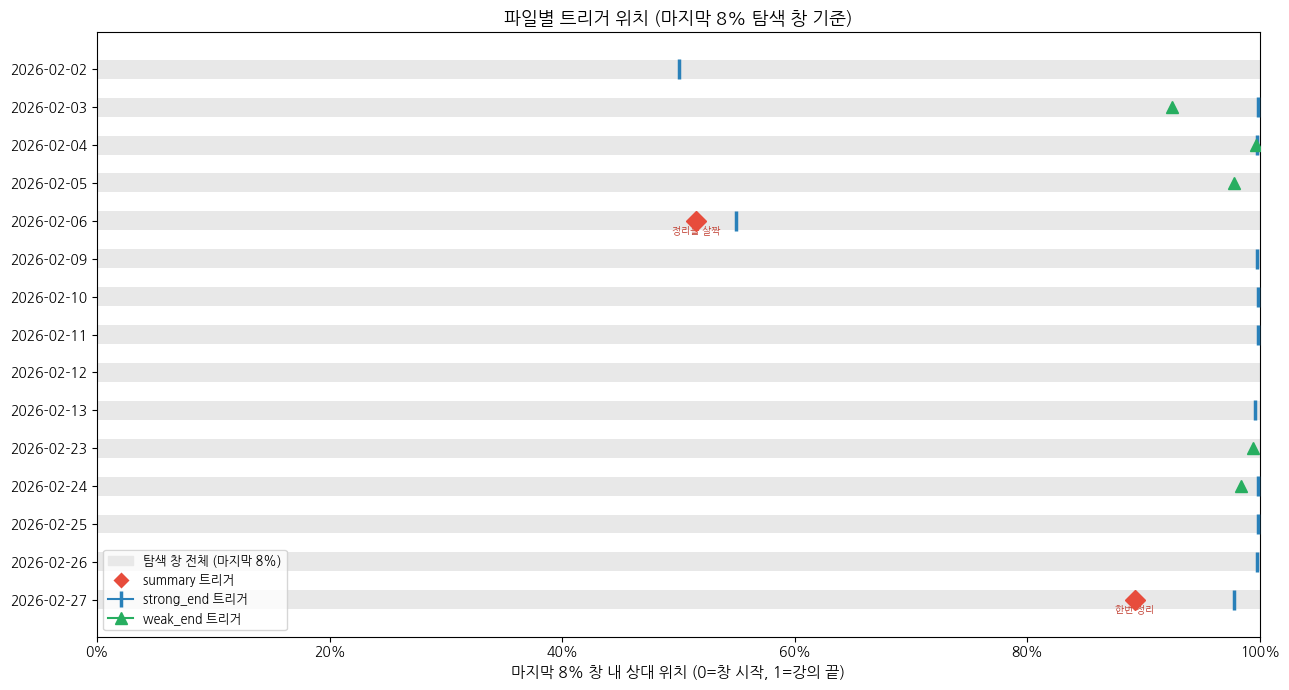

In [91]:
# ============================================================
# 10. 트리거 위치 시각화 (8% 탐색 창 내 기준)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun", "NotoSansCJK"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

rows_vis = []

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    raw = file_path.read_text(encoding="utf-8", errors="ignore")
    blocks = extract_timestamp_blocks(raw)
    n = len(blocks)
    last_n = max(MIN_LAST_BLOCKS, int(n * LAST_SECTION_RATIO))
    section = re.sub(r"\s+", " ", " ".join(b["text"] for b in blocks[-last_n:])).strip()
    total = len(section)

    s_hits = sorted([(m.start(), m.group()) for p in SUMMARY_CANDIDATE_PATTERNS for m in re.finditer(p, section)])
    e_hits = sorted([(m.start(), m.group()) for p in STRONG_END_PATTERNS        for m in re.finditer(p, section)])
    w_hits = sorted([(m.start(), m.group()) for p in WEAK_END_PATTERNS          for m in re.finditer(p, section)])

    last_s = s_hits[-1] if s_hits else None
    last_e = e_hits[-1] if e_hits else None
    last_w = w_hits[-1] if w_hits else None

    rows_vis.append({
        "file": file_path.name[:10],
        "total": total,
        "summary_pct":   last_s[0] / total if last_s else None,
        "summary_word":  last_s[1][:8]      if last_s else None,
        "strong_pct":    last_e[0] / total  if last_e else None,
        "strong_word":   last_e[1][:8]      if last_e else None,
        "weak_pct":      last_w[0] / total  if last_w else None,
        "weak_word":     last_w[1][:8]      if last_w else None,
    })

fig, ax = plt.subplots(figsize=(13, 7))
files = [r["file"] for r in rows_vis]

for i, r in enumerate(rows_vis):
    # 8% 창 전체 배경
    ax.barh(i, 1.0, left=0, height=0.5, color="#e8e8e8", zorder=1)

    # summary 트리거 (빨간 다이아몬드)
    if r["summary_pct"] is not None:
        ax.plot(r["summary_pct"], i, marker="D", color="#e74c3c", markersize=10, zorder=4)
        ax.text(r["summary_pct"], i + 0.32, r["summary_word"], fontsize=7,
                ha="center", color="#c0392b")

    # strong_end 트리거 (파란 세로선)
    if r["strong_pct"] is not None:
        ax.plot(r["strong_pct"], i, marker="|", color="#2980b9", markersize=14,
                markeredgewidth=2.5, zorder=3)

    # weak_end 트리거 (초록 세모)
    if r["weak_pct"] is not None:
        ax.plot(r["weak_pct"], i, marker="^", color="#27ae60", markersize=8, zorder=3)

ax.set_yticks(list(range(len(files))))
ax.set_yticklabels(files, fontsize=10)
ax.set_xlim(0, 1.0)
ax.set_xlabel(f"마지막 {LAST_SECTION_RATIO*100:.0f}% 창 내 상대 위치 (0=창 시작, 1=강의 끝)", fontsize=11)
ax.set_title(f"파일별 트리거 위치 (마지막 {LAST_SECTION_RATIO*100:.0f}% 탐색 창 기준)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.invert_yaxis()

legend = [
    mpatches.Patch(color="#e8e8e8", label=f"탐색 창 전체 (마지막 {LAST_SECTION_RATIO*100:.0f}%)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#e74c3c", markersize=9, label="summary 트리거"),
    plt.Line2D([0], [0], marker="|", color="#2980b9", markersize=12, markeredgewidth=2.5, label="strong_end 트리거"),
    plt.Line2D([0], [0], marker="^", color="#27ae60", markersize=8, label="weak_end 트리거"),
]
ax.legend(handles=legend, loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

In [92]:
# ============================================================
# 11. fallback_chars 근거 - 트리거별 natural context 길이 분포
#     "맥스컷 없이 트리거에서 끝까지 몇 자인가?"
# ============================================================

rows_nat = []

for file_path in sorted(SCRIPT_DIR.glob("*.txt")):
    raw = file_path.read_text(encoding="utf-8", errors="ignore")
    blocks = extract_timestamp_blocks(raw)
    n = len(blocks)
    last_n = max(MIN_LAST_BLOCKS, int(n * LAST_SECTION_RATIO))
    section = re.sub(r"\s+", " ", " ".join(b["text"] for b in blocks[-last_n:])).strip()
    total = len(section)

    result = build_llm_input_context_by_char(
        section,
        prev_chars_summary=PREV_CHARS_SUMMARY,
        prev_chars_end=PREV_CHARS_END,
        fallback_chars=FALLBACK_CHARS,
        max_context_chars=None,   # ← cap 없이 natural 길이 측정
    )

    etype = result["extraction_type"]
    trigger_pos = result["trigger_char_index_in_section"]
    start_pos   = result["start_char_index_in_section"]
    natural_len = result["original_context_char_count"]

    if etype == "fallback_last_chars":
        trigger_pct = "-"
        start_note  = f"끝에서 {FALLBACK_CHARS}자"
    else:
        trigger_pct = f"{trigger_pos/total*100:.1f}%"
        start_note  = f"{start_pos}"

    rows_nat.append({
        "file": file_path.name[:10],
        "section": total,
        "type": etype.replace("_signal_based_char","").replace("_last_chars",""),
        "trigger_pct": trigger_pct,
        "natural_len": natural_len,
        "over3000": natural_len > 3000,
    })

print(f"{'파일':<12} {'section':>7} {'type':<12} {'trigger':>8} {'natural_len':>12} {'>3000?':>7}")
print("-" * 60)
for r in rows_nat:
    flag = "★" if r["over3000"] else ""
    print(f"{r['file']:<12} {r['section']:>7} {r['type']:<12} {r['trigger_pct']:>8} {r['natural_len']:>12} {flag:>7}")

nats = [r["natural_len"] for r in rows_nat]
print(f"\n[분포] min={min(nats)}  median={sorted(nats)[len(nats)//2]}  max={max(nats)}  mean={int(sum(nats)/len(nats))}")
print(f"[3000 이하] {sum(1 for n in nats if n <= 3000)}/{len(nats)}개 파일")
print(f"[3000 초과] {sum(1 for n in nats if n > 3000)}/{len(nats)}개 파일 (max_context_chars=3000이면 절삭됨)")
print(f"\n→ fallback_chars={FALLBACK_CHARS}자 기준: 전체 섹션 중 끝 {FALLBACK_CHARS}자를 LLM에 제공")

파일           section type          trigger  natural_len  >3000?
------------------------------------------------------------
2026-02-02      6317 strong_end      50.0%         3956       ★
2026-02-03      6894 strong_end      99.8%          811        
2026-02-04      6731 strong_end      99.8%          814        
2026-02-05      5861 weak_end        97.7%          932        
2026-02-06      7016 summary         51.5%         3602       ★
2026-02-09      6215 strong_end      99.7%          816        
2026-02-10      6310 strong_end      99.8%          810        
2026-02-11      6659 strong_end      99.9%          808        
2026-02-12      4234 fallback            -         4000       ★
2026-02-13      6497 strong_end      99.6%          829        
2026-02-23      5435 weak_end        99.4%          833        
2026-02-24      6289 strong_end      99.9%          808        
2026-02-25      5338 strong_end      99.8%          810        
2026-02-26      4397 strong_end      99.8% 